In [2]:
# ============================================================
# 0. Librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Opcional: ver todas las columnas
pd.set_option("display.max_columns", None)


In [3]:
# ============================================================
# 1. Cargar datos
# ============================================================

# Ajusta la ruta si el archivo está en otra carpeta
ruta_archivo = "/Users/karlavega/Proyectos/Colaborativos/Forest_Peru/Datos/resultados_distrital.xlsx"

df = pd.read_excel(
    ruta_archivo,
    sheet_name="resultados_onpe_erm2022_por_dis"
)

print(df.head())
print(df.dtypes)


   ubigeo    region    provincia  distrito  \
0   10102  Amazonas  Chachapoyas  Asunción   
1   10102  Amazonas  Chachapoyas  Asunción   
2   10103  Amazonas  Chachapoyas    Balsas   
3   10103  Amazonas  Chachapoyas    Balsas   
4   10103  Amazonas  Chachapoyas    Balsas   

                     organizacion_politica  total_votos  orden_aparicion  
0  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE          108                1  
1                 ALIANZA PARA EL PROGRESO          159                2  
2          SENTIMIENTO AMAZONENSE REGIONAL          120                1  
3  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE           40                2  
4                       RENOVACION POPULAR          130                3  
ubigeo                    int64
region                   object
provincia                object
distrito                 object
organizacion_politica    object
total_votos               int64
orden_aparicion           int64
dtype: object


In [4]:
# ============================================================
# 2. Construir variables X, Y y dummy de ganador
# ============================================================

# X = posición en la cédula
df["X_posicion"] = df["orden_aparicion"]

# Ganador por distrito: máximo de votos dentro de cada ubigeo
df["max_votos_distrito"] = df.groupby("ubigeo")["total_votos"].transform("max")

# Y = dummy de ganador: 1 si el partido ganó en ese distrito, 0 si no
# (si hay empate en el máximo, todos los empatados quedan como ganadores)
df["Y_gano"] = (df["total_votos"] == df["max_votos_distrito"]).astype(int)

# Vista rápida para verificar
print(
    df[[
        "ubigeo", "distrito", "organizacion_politica",
        "total_votos", "orden_aparicion", "X_posicion", "Y_gano"
    ]].head(22)
)


    ubigeo     distrito                    organizacion_politica  total_votos  \
0    10102     Asunción  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE          108   
1    10102     Asunción                 ALIANZA PARA EL PROGRESO          159   
2    10103       Balsas          SENTIMIENTO AMAZONENSE REGIONAL          120   
3    10103       Balsas  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE           40   
4    10103       Balsas                       RENOVACION POPULAR          130   
5    10103       Balsas                 ALIANZA PARA EL PROGRESO          248   
6    10104        Cheto          SENTIMIENTO AMAZONENSE REGIONAL          203   
7    10104        Cheto  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE          294   
8    10104        Cheto     PARTIDO POLITICO NACIONAL PERU LIBRE           17   
9    10105    Chiliquin          SENTIMIENTO AMAZONENSE REGIONAL          212   
10   10105    Chiliquin  MOVIMIENTO REGIONAL VICTORIA AMAZONENSE          131   
11   10105    Chiliquin     

In [10]:
# ============================================================
# 3. Probabilidad empírica de ganar por posición
# ============================================================

prob_por_pos = (
    df.groupby("X_posicion")["Y_gano"]
      .mean()
      .reset_index()
      .rename(columns={"Y_gano": "prob_ganar"})
)

print(prob_por_pos)


    X_posicion  prob_ganar
0            1    0.256653
1            2    0.229067
2            3    0.208750
3            4    0.161455
4            5    0.153000
5            6    0.144756
6            7    0.090069
7            8    0.081784
8            9    0.086093
9           10    0.032609
10          11    0.067797
11          12    0.057143
12          13    0.000000
13          14    0.000000
14          15    0.000000
15          16    0.000000


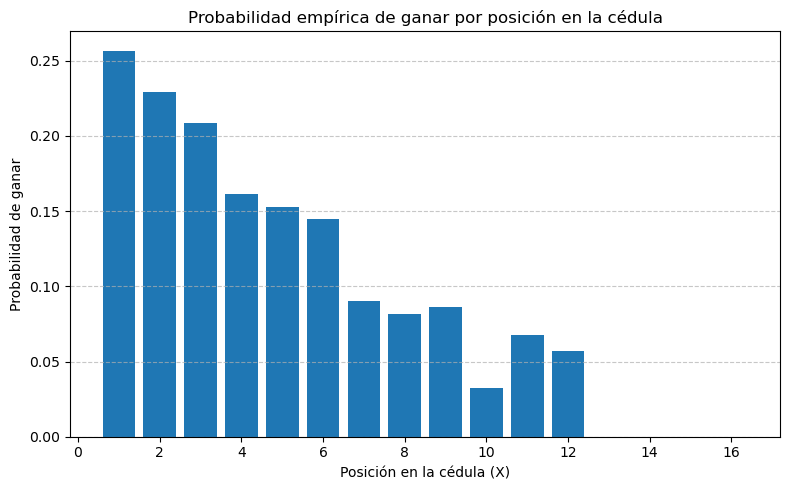

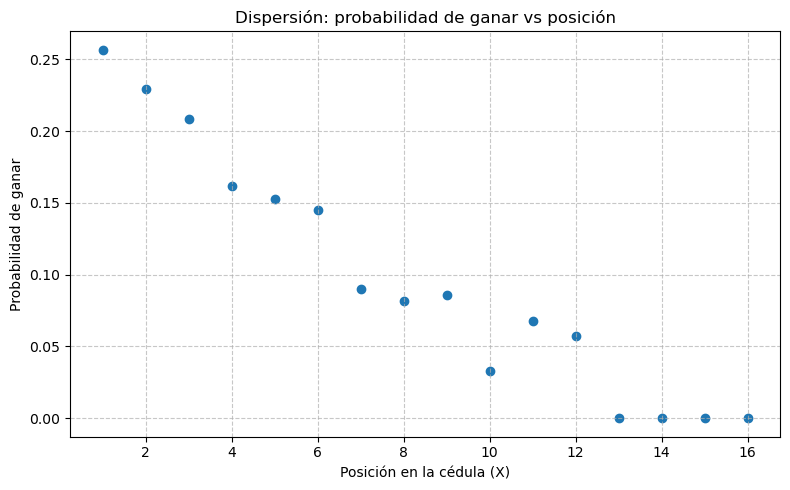

In [12]:
# ============================================================
# 4. GRÁFICOS
#   4.1 Barras: probabilidad de ganar por posición
#   4.2 Dispersión: probabilidad de ganar vs posición
# ============================================================

# -------- 4.1 Barras --------
plt.figure(figsize=(8, 5))
plt.bar(prob_por_pos["X_posicion"], prob_por_pos["prob_ganar"])

plt.xlabel("Posición en la cédula (X)")
plt.ylabel("Probabilidad de ganar")
plt.title("Probabilidad empírica de ganar por posición en la cédula")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# -------- 4.2 Dispersión (scatter) --------
plt.figure(figsize=(8, 5))
plt.scatter(prob_por_pos["X_posicion"], prob_por_pos["prob_ganar"])

# Opcional: unir puntos para ver la tendencia
# plt.plot(prob_por_pos["X_posicion"], prob_por_pos["prob_ganar"])

plt.xlabel("Posición en la cédula (X)")
plt.ylabel("Probabilidad de ganar")
plt.title("Dispersión: probabilidad de ganar vs posición")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 5. Preparar datos para regresiones
#    (quitamos NAs en variables clave)
# ============================================================

reg_data = df.dropna(subset=["Y_gano", "X_posicion", "provincia", "ubigeo"])


In [16]:
# ============================================================
# 6. Modelo Lineal de Probabilidad (LPM)
#    con efectos fijos por provincia y clustering por distrito
# ============================================================

# Y_gano ~ posición + efectos fijos de provincia
formula_lpm = "Y_gano ~ X_posicion + C(provincia)"

modelo_lpm_cluster = smf.ols(
    formula=formula_lpm,
    data=reg_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_data["ubigeo"]}  # clustering por distrito (ubigeo)
)

print(modelo_lpm_cluster.summary())


                            OLS Regression Results                            
Dep. Variable:                 Y_gano   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     72.07
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:34:29   Log-Likelihood:                -4213.0
No. Observations:                9091   AIC:                             8818.
Df Residuals:                    8895   BIC:                         1.021e+04
Df Model:                         195                                         
Covariance Type:              cluster                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 195, but rank is 191
  warnings.warn('covariance of constraints does not have full '


In [18]:
# ============================================================
# 7. Logit con efectos fijos por provincia + clustering por distrito
#    (CORREGIDO: sin get_robustcov_results)
# ============================================================

formula_logit = "Y_gano ~ X_posicion + C(provincia)"

modelo_logit_cluster = smf.logit(
    formula=formula_logit,
    data=reg_data
).fit(
    disp=True,                 # o False si no quieres ver el proceso
    cov_type="cluster",        # tipo de var-cov
    cov_kwds={"groups": reg_data["ubigeo"]}  # clustering por distrito
)

print(modelo_logit_cluster.summary())


Optimization terminated successfully.
         Current function value: 0.467063
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Y_gano   No. Observations:                 9091
Model:                          Logit   Df Residuals:                     8895
Method:                           MLE   Df Model:                          195
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                 0.03294
Time:                        16:37:49   Log-Likelihood:                -4246.1
converged:                       True   LL-Null:                       -4390.7
Covariance Type:              cluster   LLR p-value:                 1.343e-05
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -